# Auditoría de Calidad de Datos — NovaMarket

**Asignatura:** Preprocesamiento de datos

**Grupo:** 05

**Integrantes:** María Andrea Torres, Ricardo Borja, Gabriel Murillo Velandia y Laura Marcela Gómez

**Fecha:** Agosto 01 de 2026


## 1. Introducción

**Objetivo.** Realizar una auditoría de calidad sobre el dataset de ventas de NovaMarket, diagnosticando su estado en las seis dimensiones de calidad de datos (completitud, exactitud, consistencia, validez, unicidad y oportunidad), cuantificando cada problema encontrado con cifras y porcentajes.

Parte del diagnóstico se apoya en una **fuente externa oficial** para la dimensión de exactitud: el catálogo de códigos postales de Colombia (Datos Abiertos / 4-72), contra el cual se contrasta la coherencia entre `codigo_postal` y `ciudad`.

## Instalación librerias

In [80]:
from pandas import read_csv
!pip install pandas tabulate


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Importación librerias

In [81]:
import pandas as pd
import unicodedata

from IPython.display import display
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np


## Carga Base de Datos

In [82]:
df = pd.read_csv("NovaMarket_datos_crudos.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_pedido                  620 non-null    object 
 1   id_cliente                 620 non-null    object 
 2   fecha_compra               620 non-null    object 
 3   canal                      620 non-null    object 
 4   ciudad                     589 non-null    object 
 5   codigo_postal              620 non-null    int64  
 6   categoria_producto         620 non-null    object 
 7   producto                   620 non-null    object 
 8   precio                     599 non-null    float64
 9   unidades                   620 non-null    int64  
 10  edad_cliente               620 non-null    int64  
 11  correo                     516 non-null    object 
 12  nivel_satisfaccion         574 non-null    object 
 13  fecha_actualizacion_stock  620 non-null    object 

### Variables
- Se identifican 14 variables agrupadas por nivel de medición de la siguiente manera:
    - Ordinales: nivel_satisfacción, codigo_postal
    - Nominales: id_pedido, id_cliente, categoria_producto, canal, producto, correo, ciudad
    - Intervalo: fecha_compra, fecha_actualizacion_stock, edad_cliente
    - Razón: unidades, precio

- Tenemos 10 variables tipo string, 3 tipo integer y 1 tipo float

In [83]:
df.head()

,id_pedido,id_cliente,fecha_compra,canal,ciudad,codigo_postal,categoria_producto,producto,precio,unidades,edad_cliente,correo,nivel_satisfaccion,fecha_actualizacion_stock
0,P00383,C0276,2026-01-03,App,Bucaramanga,68001,Belleza,Camiseta,-1742611.0,4,-19,c0276gmail.com,alto,2026-07-01
1,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,1828583.0,2,23,c0167@hotmail.com,MEDIO,2026-07-01
2,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,1828583.0,2,23,c0167@hotmail.com,MEDIO,2026-07-01
3,P00450,C0128,07/09/2026,App,bucaramanga,68001,electronica,Set bloques,787178.0,6,69,c0128@hotmail.com,MEDIO,2026-07-15
4,P00449,C0304,2025-07-19,Tienda,Bogotá,8001,Belleza,Audífonos BT,357231.0,5,67,c0304@novamarket.co,Bajo,2026-05-20


In [84]:
df.describe(include='all')

,id_pedido,id_cliente,fecha_compra,canal,ciudad,codigo_postal,categoria_producto,producto,precio,unidades,edad_cliente,correo,nivel_satisfaccion,fecha_actualizacion_stock
count,620,620,620,620,589,620.000000,620,620,5.990000e+02,620.000000,620.000000,516,574,620
unique,600,311,495,3,19,NaN,17,14,NaN,NaN,NaN,429,8,8
top,P00201,C0043,15/11/2027,Tienda,bucaramanga,NaN,Belleza,Perfume,NaN,NaN,NaN,c0012@hotmail.com,Alto,2026-07-15
freq,2,6,9,224,58,NaN,66,52,NaN,NaN,NaN,4,91,152
mean,NaN,NaN,NaN,NaN,NaN,31917.129032,NaN,NaN,4.888703e+06,188.682258,48.012903,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,30339.586863,NaN,NaN,4.292512e+07,1240.652475,28.668511,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,5001.000000,NaN,NaN,-2.448455e+06,-3.000000,-20.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,8001.000000,NaN,NaN,5.914020e+05,2.000000,31.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,13001.000000,NaN,NaN,1.178666e+06,3.000000,46.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,68001.000000,NaN,NaN,1.856670e+06,5.000000,63.000000,NaN,NaN,NaN


### Datos

Observamos que los datos tienen varias problemáticas como formatos de fecha distintos en la misma columna, nombres de categoria con significado similar pero escritos de diferente manera, incongruencia en datos numéricos que no deberían ser negativos.

## Diagnóstico por dimensión

### Completitud

In [85]:
null_data = df.isnull().sum()
completeness = (1 - df.isnull().mean()) * 100
#print(100 - completeness.round(2).sort_values())

Los valores faltantes se encuentran distribuidos así:

| Columna | Faltantes | % faltante | Nivel | Razón |
|---------------------|-----------|------------|--------------|----------------------------------------------------------------------------------------------------------------------------------------------|
| correo              | 104       | 16.77%     | Bajo impacto | Es la de mayor volumen de faltantes, pero no entra en promedios, sumas ni modelos, así que su impacto operativo es bajo; puede dejarse vacía o marcarse como desconocido. |
| nivel_satisfaccion  | 46        | 7.42%      | Moderado     | Es una variable categórica susceptible a estar vacía porque no siempre se llena; su ausencia es esperable y puede imputarse como categoría "sin dato". |
| ciudad              | 31        | 5.00%      | Moderado     | Es útil para segmentación y varios cálculos, pero con solo 5% de ausencia la pérdida de representatividad es contenida. |
| precio              | 21        | 3.39%      | Moderado     | Es clave para los cálculos estadísticos; aunque la ausencia es baja, conviene imputar (p. ej. mediana) antes que eliminar registros para no sesgar la tendencia central. |

**Visualización % de valores faltantes por columna.** El gráfico ordena las columnas por proporción de faltantes, haciendo visible de un vistazo dónde se concentra el problema de completitud que la tabla anterior cuantifica.


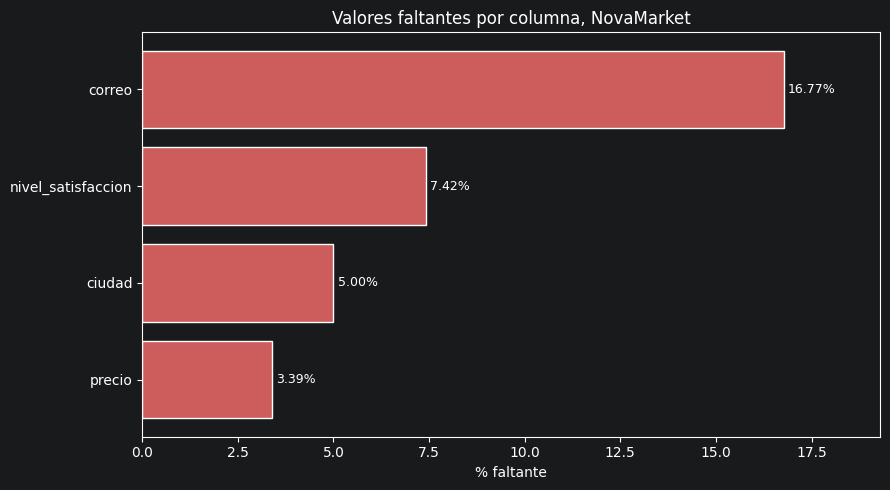

In [86]:
# Gráfico de completitud: % de faltantes por columna (ordenado)
faltantes_pct = (100 - completeness).sort_values(ascending=True)
faltantes_pct = faltantes_pct[faltantes_pct > 0]  # solo columnas con faltantes

plt.figure(figsize=(9, 5))
barras = plt.barh(faltantes_pct.index, faltantes_pct.values,
                  color="indianred", edgecolor="white")
plt.bar_label(barras, fmt="%.2f%%", padding=3, fontsize=9)
plt.title("Valores faltantes por columna, NovaMarket")
plt.xlabel("% faltante")
plt.xlim(0, faltantes_pct.max() * 1.15)
plt.tight_layout()
plt.show()


### Validez

Se verifica que los valores cumplan el formato o regla esperada: los identificadores contra su patrón, y las fechas contra un formato de fecha reconocible.

In [87]:
col = 'id_pedido'
pattern = r'^P\d{5}$'
n = len(df)

valid_mask = df[col].str.match(pattern).fillna(False)
total_validos   = valid_mask.sum()
total_invalidos = (~valid_mask).sum()

pct_falla_id = total_invalidos / n * 100

audit_id = pd.DataFrame([{
    "Columna":            "id_pedido",
    "Formatos Validos":   total_validos,
    "Formatos Invalidos": total_invalidos,
    "% Falla":            f"{pct_falla_id:.2f}%",
}])

audit_id.style.hide(axis="index")


Columna,Formatos Validos,Formatos Invalidos,% Falla
id_pedido,620,0,0.00%


In [88]:
col = 'id_cliente'
pattern = r'^C\d{4}$'

valid_mask = df[col].str.match(pattern).fillna(False)
total_validos = valid_mask.sum()
total_invalidos = (~valid_mask).sum()

id_cliente_pct = total_invalidos / len(df) * 100

audit_id_cliente = pd.DataFrame([{
    "Columna":            "id_cliente",
    "Formatos Validos":   total_validos,
    "Formatos Invalidos": total_invalidos,
    "% Falla":            f"{id_cliente_pct:.2f}%",
}])

audit_id_cliente.style.hide(axis="index")

Columna,Formatos Validos,Formatos Invalidos,% Falla
id_cliente,620,0,0.00%


In [89]:
current_date = pd.to_datetime(datetime.now().date())

df['purchase_dates_converted'] = pd.to_datetime(df['fecha_compra'], format='mixed', errors='coerce')
df['stock_update_dates_converted'] = pd.to_datetime(df['fecha_actualizacion_stock'], format='mixed', errors='coerce')

total_purchase_invalid_formats = df['purchase_dates_converted'].isna().sum()
total_purchase_valid_formats = df['purchase_dates_converted'].notna().sum()

df['purchase_out_of_range'] = df['purchase_dates_converted'] >= current_date
total_purchase_out_of_range = df['purchase_out_of_range'].sum()

total_stock_invalid_formats = df['stock_update_dates_converted'].isna().sum()
total_stock_valid_formats = df['stock_update_dates_converted'].notna().sum()

df['stock_out_of_range'] = df['stock_update_dates_converted'] >= current_date
total_stock_out_of_range = df['stock_out_of_range'].sum()

purchase_no_valid_percentage = (total_purchase_invalid_formats) / len(df) * 100 + (total_purchase_out_of_range) / len(df) * 100
stock_no_valid_percentage = (total_stock_invalid_formats) / len(df) * 100 + (total_stock_out_of_range) / len(df) * 100

audit_dates = pd.DataFrame([
    {
        "Columna":            "fecha_compra",
        "Formatos Validos":   total_purchase_valid_formats,
        "Formatos Invalidos": total_purchase_invalid_formats,
        "Fuera de Rango":     total_purchase_out_of_range,
        "% Falla":            f"{purchase_no_valid_percentage:.2f}%",
    },
    {
        "Columna":            "fecha_actualizacion_stock",
        "Formatos Validos":   total_stock_valid_formats,
        "Formatos Invalidos": total_stock_invalid_formats,
        "Fuera de Rango":     total_stock_out_of_range,
        "% Falla":            f"{stock_no_valid_percentage:.2f}%",
    },
])

audit_dates.style.hide(axis="index")

Columna,Formatos Validos,Formatos Invalidos,Fuera de Rango,% Falla
fecha_compra,598,22,126,23.87%
fecha_actualizacion_stock,620,0,21,3.39%


**Rangos numéricos** (precio, unidades, edad)

In [90]:
n = len(df)

reglas = {
    "precio":       lambda s: (s <= 0),                 # un precio de venta no puede ser <= 0
    "unidades":     lambda s: (s <= 0),                 # una compra debe tener al menos 1 unidad
    "edad_cliente": lambda s: (s < 0) | (s > 120),      # edad humana fuera de rango
}

filas = []
for col, es_invalido in reglas.items():
    serie = df[col]
    invalidos = es_invalido(serie).fillna(False).sum()
    nulos     = serie.isna().sum()
    validos   = n - invalidos - nulos
    filas.append({
        "Columna":   col,
        "Validos":   validos,
        "Invalidos": invalidos,
        "Nulos":     nulos,
        "% Falla":   f"{invalidos / n * 100:.2f}%",
    })

audit_rangos = pd.DataFrame(filas)
audit_rangos.style.hide(axis="index")


Columna,Validos,Invalidos,Nulos,% Falla
precio,580,19,21,3.06%
unidades,589,31,0,5.00%
edad_cliente,588,32,0,5.16%


**Visualización dispersión y valores fuera de rango.** Para cada variable numérica con regla de dominio se muestran dos vistas complementarias. A la izquierda, un **gráfico de dispersión a escala completa**: cada registro es un punto, los que violan la regla aparecen en rojo y la línea punteada marca el umbral; así se ven los valores imposibles y los outliers extremos. A la derecha, un **boxplot con la escala ajustada** al rango de Tukey (Q1−1.5·IQR a Q3+1.5·IQR), que hace visible la caja y los bigotes —imposible de apreciar a escala completa porque los outliers la aplastan contra el cero—.


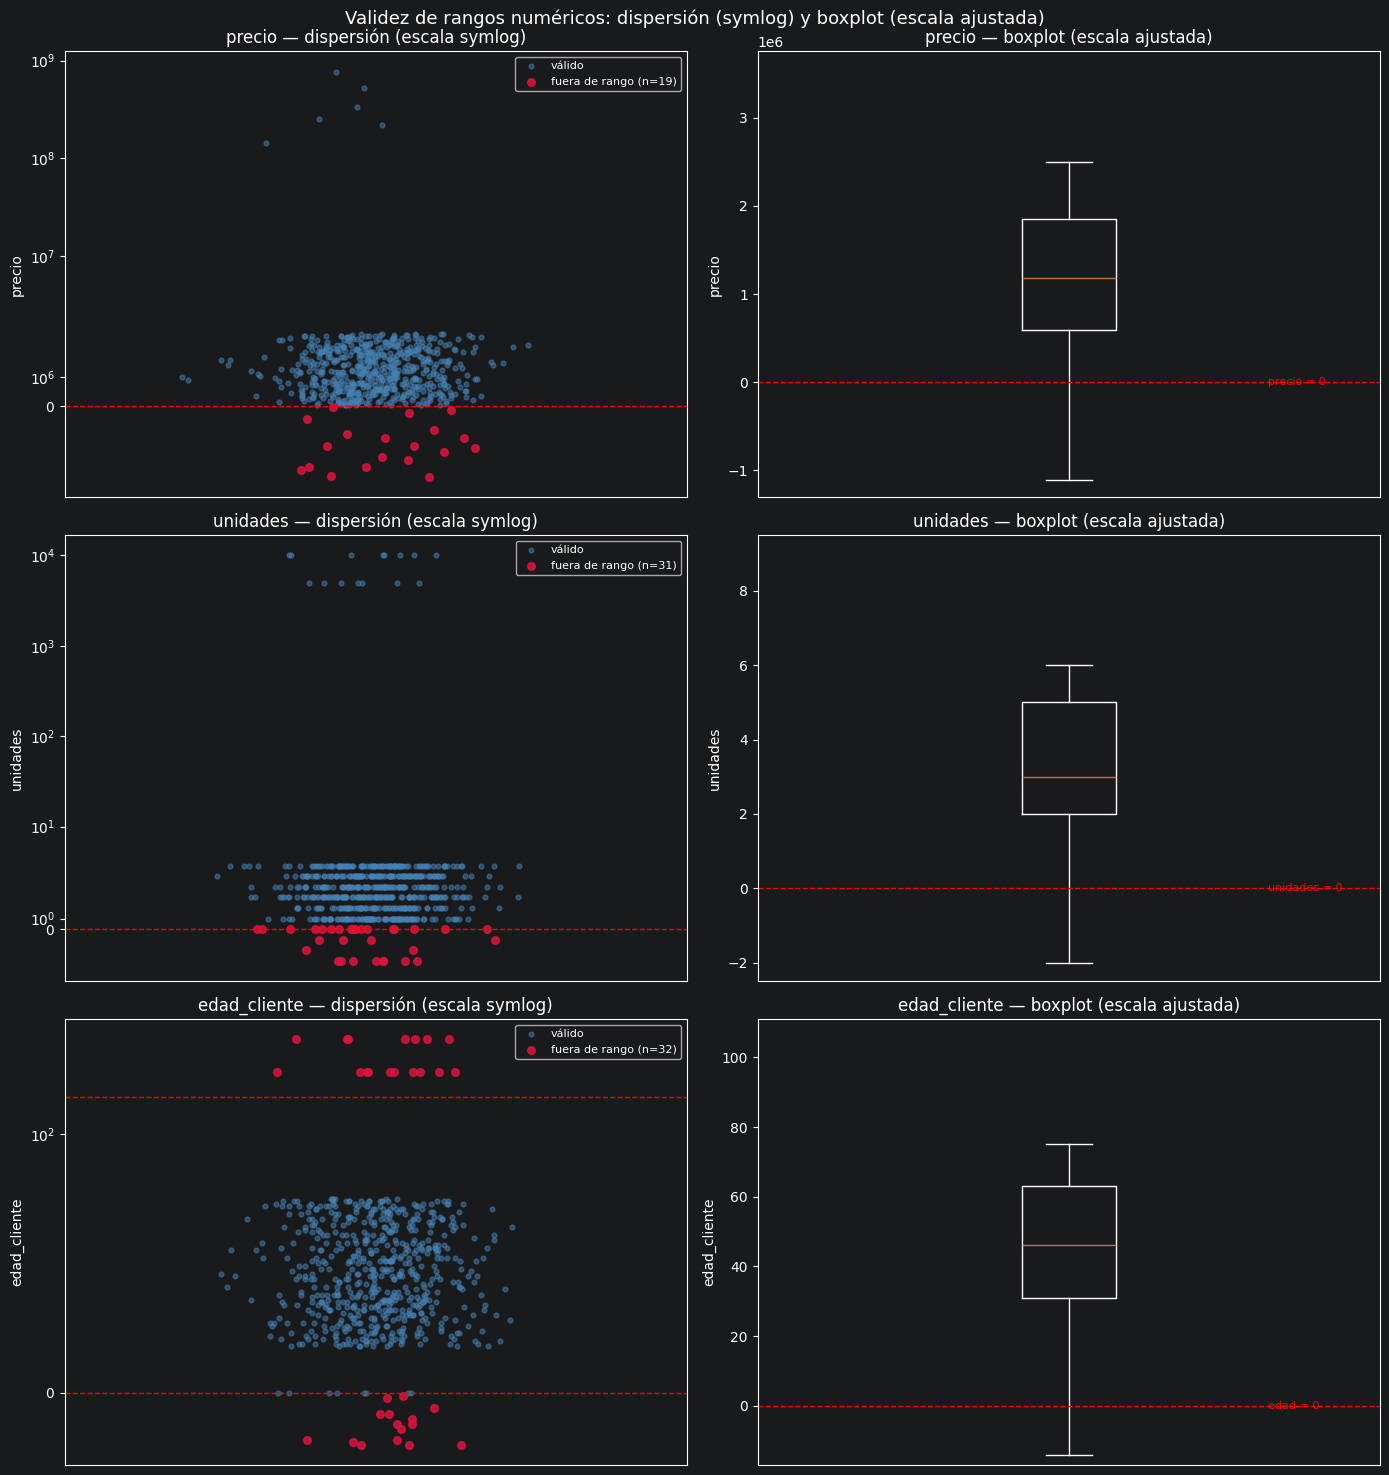

In [102]:
# Dispersión (escala symlog: ve el grueso Y los outliers) + boxplot (escala ajustada)
reglas_viz = {
    "precio":       {"invalido": lambda s: s <= 0,              "umbral": [(0, "precio = 0")]},
    "unidades":     {"invalido": lambda s: s <= 0,              "umbral": [(0, "unidades = 0")]},
    "edad_cliente": {"invalido": lambda s: (s < 0) | (s > 120), "umbral": [(0, "edad = 0"), (120, "edad = 120")]},
}

rng = np.random.default_rng(0)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for fila, (col, cfg) in enumerate(reglas_viz.items()):
    serie = df[col].dropna()
    mask  = cfg["invalido"](serie)               # True = fuera de rango
    n_inv = int(mask.sum())

    # umbral lineal de symlog = cerca de Tukey (mismo criterio que el boxplot)
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    fence = (q3 + 1.5 * iqr) if iqr > 0 else serie.abs().max()
    linthresh = max(abs(fence), 1)

    # --- Izquierda: dispersión con escala symlog ---
    ax = axes[fila, 0]
    x_jit = rng.normal(0, 0.04, size=len(serie))
    ax.scatter(x_jit[~mask.values], serie[~mask.values],
               s=12, color="steelblue", alpha=0.5, label="válido")
    ax.scatter(x_jit[mask.values], serie[mask.values],
               s=30, color="crimson", alpha=0.85, label=f"fuera de rango (n={n_inv})")
    ax.set_yscale("symlog", linthresh=linthresh)
    for y, _ in cfg["umbral"]:
        ax.axhline(y, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{col} — dispersión (escala symlog)")
    ax.set_ylabel(col)
    ax.set_xlim(-0.25, 0.25)
    ax.set_xticks([])
    ax.legend(fontsize=8, loc="upper right")

    # --- Derecha: boxplot con escala ajustada (rango de Tukey) ---
    ax2 = axes[fila, 1]
    ax2.boxplot(serie, vert=True, showfliers=False)
    if iqr > 0:
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        ax2.set_ylim(lo, hi)
        for y, etiqueta in cfg["umbral"]:
            if lo <= y <= hi:
                ax2.axhline(y, color="red", linestyle="--", linewidth=1)
                ax2.text(1.32, y, etiqueta, color="red", va="center", fontsize=8)
    ax2.set_title(f"{col} — boxplot (escala ajustada)")
    ax2.set_ylabel(col)
    ax2.set_xticks([])

plt.suptitle("Validez de rangos numéricos: dispersión (symlog) y boxplot (escala ajustada)",
             fontsize=13)
plt.tight_layout()
plt.show()


**Formato de correo**

In [92]:
col = 'correo'
pattern = r'^[^@\s]+@[^@\s]+\.[^@\s]+$'

valid_mask = df[col].str.match(pattern).astype('boolean').fillna(False)
total_validos   = valid_mask.sum()
total_nulos     = df[col].isna().sum()
total_invalidos = (~valid_mask & df[col].notna()).sum()

pct_falla = total_invalidos / len(df) * 100

audit_correo = pd.DataFrame([{
    "Columna":            col,
    "Formatos Validos":   int(total_validos),
    "Formatos Invalidos": int(total_invalidos),
    "Nulos":              int(total_nulos),
    "% Falla":            f"{pct_falla:.2f}%",
}])

audit_correo.style.hide(axis="index")

Columna,Formatos Validos,Formatos Invalidos,Nulos,% Falla
correo,465,51,104,8.23%


### Consistencia

Se verifica que un mismo concepto esté representado de forma uniforme, sin variantes de escritura (mayúsculas, tildes o sinónimos) que fragmenten una misma categoría. La forma canónica se toma como la variante más frecuente de cada grupo.

**Canal**

In [93]:
tabla_canal = df['canal'].value_counts(dropna=False).rename_axis('canal').reset_index(name='conteo')
tabla_canal['%'] = (tabla_canal['conteo'] / len(df) * 100).round(2).astype(str) + '%'

tabla_canal.style.hide(axis="index")

canal,conteo,%
Tienda,224,36.13%
App,218,35.16%
Web,178,28.71%


**Ciudad**

In [94]:
equivalencias = {
    'b/quilla':    'barranquilla',
    'bogota d.c.': 'bogota',
    'bogota dc':   'bogota',
}

def normalizar(s):
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    s = ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    return equivalencias.get(s, s)

ciudad_norm = df['ciudad'].map(normalizar)

tabla_exactitud = (
    df.assign(ciudad_norm=ciudad_norm)
      .dropna(subset=['ciudad'])
      .groupby('ciudad_norm')
      .agg(
          variantes = ('ciudad', 'nunique'),
          registros = ('ciudad', 'size'),
          canonica  = ('ciudad', lambda x: x.mode()[0]),
          desviados = ('ciudad', lambda x: (x != x.mode()[0]).sum()),
          formas    = ('ciudad', lambda x: ', '.join(sorted(x.unique()))),
      )
      .sort_values('desviados', ascending=False)
      .reset_index()
)

tabla_exactitud['inconsistente'] = tabla_exactitud['variantes'] > 1
tabla_exactitud['%'] = (tabla_exactitud['desviados'] / tabla_exactitud['registros'] * 100).round(2).astype(str) + '%'

display(tabla_exactitud.style.hide(axis="index"))

_reg  = tabla_exactitud["registros"].sum()          # registros no nulos de la columna
_desv = tabla_exactitud["desviados"].sum()           # registros fuera de la forma canónica (datos malos)
_total = len(df)                              # total de la base de datos
_pct_bd  = _desv / _total * 100               # % sobre el total de la BD
resumen = pd.DataFrame([{
    "Columna":                 "ciudad",
    "Registros a ajustar":     int(_desv),
    "Total BD":                int(_total),
    "% del total de la BD":    f"{_pct_bd:.2f}%",
}])
display(resumen.style.hide(axis="index"))


ciudad_norm,variantes,registros,canonica,desviados,formas,inconsistente,%
bogota,5,93,BOGOTÁ,72,"BOGOTÁ, Bogota, Bogotá, Bogotá D.C., bogota",True,77.42%
cali,3,104,cali,65,"CALI, Cali, cali",True,62.5%
medellin,4,97,medellin,65,"MEDELLIN, Medellin, Medellín, medellin",True,67.01%
barranquilla,3,88,barranquilla,52,"B/quilla, Barranquilla, barranquilla",True,59.09%
cartagena,2,102,CARTAGENA,50,"CARTAGENA, Cartagena",True,49.02%
bucaramanga,2,105,bucaramanga,47,"Bucaramanga, bucaramanga",True,44.76%


Columna,Registros a ajustar,Total BD,% del total de la BD
ciudad,351,620,56.61%


**Categoría de producto**

In [95]:
equiv_categoria = {
    'juguetes': 'jugueteria',   # juguetes y juguetería se tratan como la misma categoría
}

def normalizar_categoria(s):
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    s = ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    return equiv_categoria.get(s, s)

cat_norm = df['categoria_producto'].map(normalizar_categoria)

tabla_categoria = (
    df.assign(cat_norm=cat_norm)
      .dropna(subset=['categoria_producto'])
      .groupby('cat_norm')
      .agg(
          variantes = ('categoria_producto', 'nunique'),
          registros = ('categoria_producto', 'size'),
          canonica  = ('categoria_producto', lambda x: x.mode()[0]),
          desviados = ('categoria_producto', lambda x: (x != x.mode()[0]).sum()),
          formas    = ('categoria_producto', lambda x: ', '.join(sorted(x.unique()))),
      )
      .sort_values('desviados', ascending=False)
      .reset_index()
)

tabla_categoria['inconsistente'] = tabla_categoria['variantes'] > 1
tabla_categoria['%'] = (tabla_categoria['desviados'] / tabla_categoria['registros'] * 100).round(2).astype(str) + '%'

display(tabla_categoria.style.hide(axis="index"))

_reg  = tabla_categoria["registros"].sum()          # registros no nulos de la columna
_desv = tabla_categoria["desviados"].sum()           # registros fuera de la forma canónica (datos malos)
_total = len(df)                              # total de la base de datos
_pct_bd  = _desv / _total * 100               # % sobre el total de la BD
resumen = pd.DataFrame([{
    "Columna":                 "categoria_producto",
    "Registros a ajustar":     int(_desv),
    "Total BD":                int(_total),
    "% del total de la BD":    f"{_pct_bd:.2f}%",
}])
display(resumen.style.hide(axis="index"))


cat_norm,variantes,registros,canonica,desviados,formas,inconsistente,%
hogar,3,99,HOGAR,65,"HOGAR, Hogar, hogar",True,65.66%
deportes,2,119,deportes,59,"Deportes, deportes",True,49.58%
moda,3,98,Moda,59,"MODA, Moda, moda",True,60.2%
jugueteria,3,95,Juguetería,58,"Jugueteria, Juguetería, juguetes",True,61.05%
electronica,4,89,Electronica,56,"ELECTRONICA, Electronica, Electrónica, electronica",True,62.92%
belleza,2,120,Belleza,54,"Belleza, belleza",True,45.0%


Columna,Registros a ajustar,Total BD,% del total de la BD
categoria_producto,351,620,56.61%


**Nivel de satisfacción**

In [96]:
tabla_nivel = (
    df.assign(nivel_norm=df['nivel_satisfaccion'].map(normalizar))
      .dropna(subset=['nivel_satisfaccion'])
      .groupby('nivel_norm')
      .agg(
          variantes = ('nivel_satisfaccion', 'nunique'),
          registros = ('nivel_satisfaccion', 'size'),
          canonica  = ('nivel_satisfaccion', lambda x: x.mode()[0]),
          desviados = ('nivel_satisfaccion', lambda x: (x != x.mode()[0]).sum()),
          formas    = ('nivel_satisfaccion', lambda x: ', '.join(sorted(map(str, x.unique())))),
      )
      .sort_values('desviados', ascending=False)
      .reset_index()
)
tabla_nivel['inconsistente'] = tabla_nivel['variantes'] > 1
tabla_nivel['%'] = (tabla_nivel['desviados'] / tabla_nivel['registros'] * 100).round(2).astype(str) + '%'

display(tabla_nivel.style.hide(axis="index"))

_reg  = tabla_nivel["registros"].sum()          # registros no nulos de la columna
_desv = tabla_nivel["desviados"].sum()           # registros fuera de la forma canónica (datos malos)
_total = len(df)                              # total de la base de datos
_pct_bd  = _desv / _total * 100               # % sobre el total de la BD
resumen = pd.DataFrame([{
    "Columna":                 "nivel_satisfaccion",
    "Registros a ajustar":     int(_desv),
    "Total BD":                int(_total),
    "% del total de la BD":    f"{_pct_bd:.2f}%",
}])
display(resumen.style.hide(axis="index"))


nivel_norm,variantes,registros,canonica,desviados,formas,inconsistente,%
alto,3,242,Alto,151,"ALTO, Alto, alto",True,62.4%
medio,3,197,Medio,123,"MEDIO, Medio, medio",True,62.44%
bajo,2,135,bajo,62,"Bajo, bajo",True,45.93%


Columna,Registros a ajustar,Total BD,% del total de la BD
nivel_satisfaccion,336,620,54.19%


**Visualización — fragmentación de categorías (antes vs. después).** Para las tres columnas de mayor impacto (ciudad, categoria_producto y nivel_satisfaccion), se contrasta el conteo con la escritura **cruda** —donde una misma clase aparece partida en varias variantes (mayúsculas, tildes, sinónimos)— frente al conteo tras **normalizar** a la forma canónica. La reducción de barras es la evidencia visual del problema de consistencia y del efecto de la corrección recomendada.


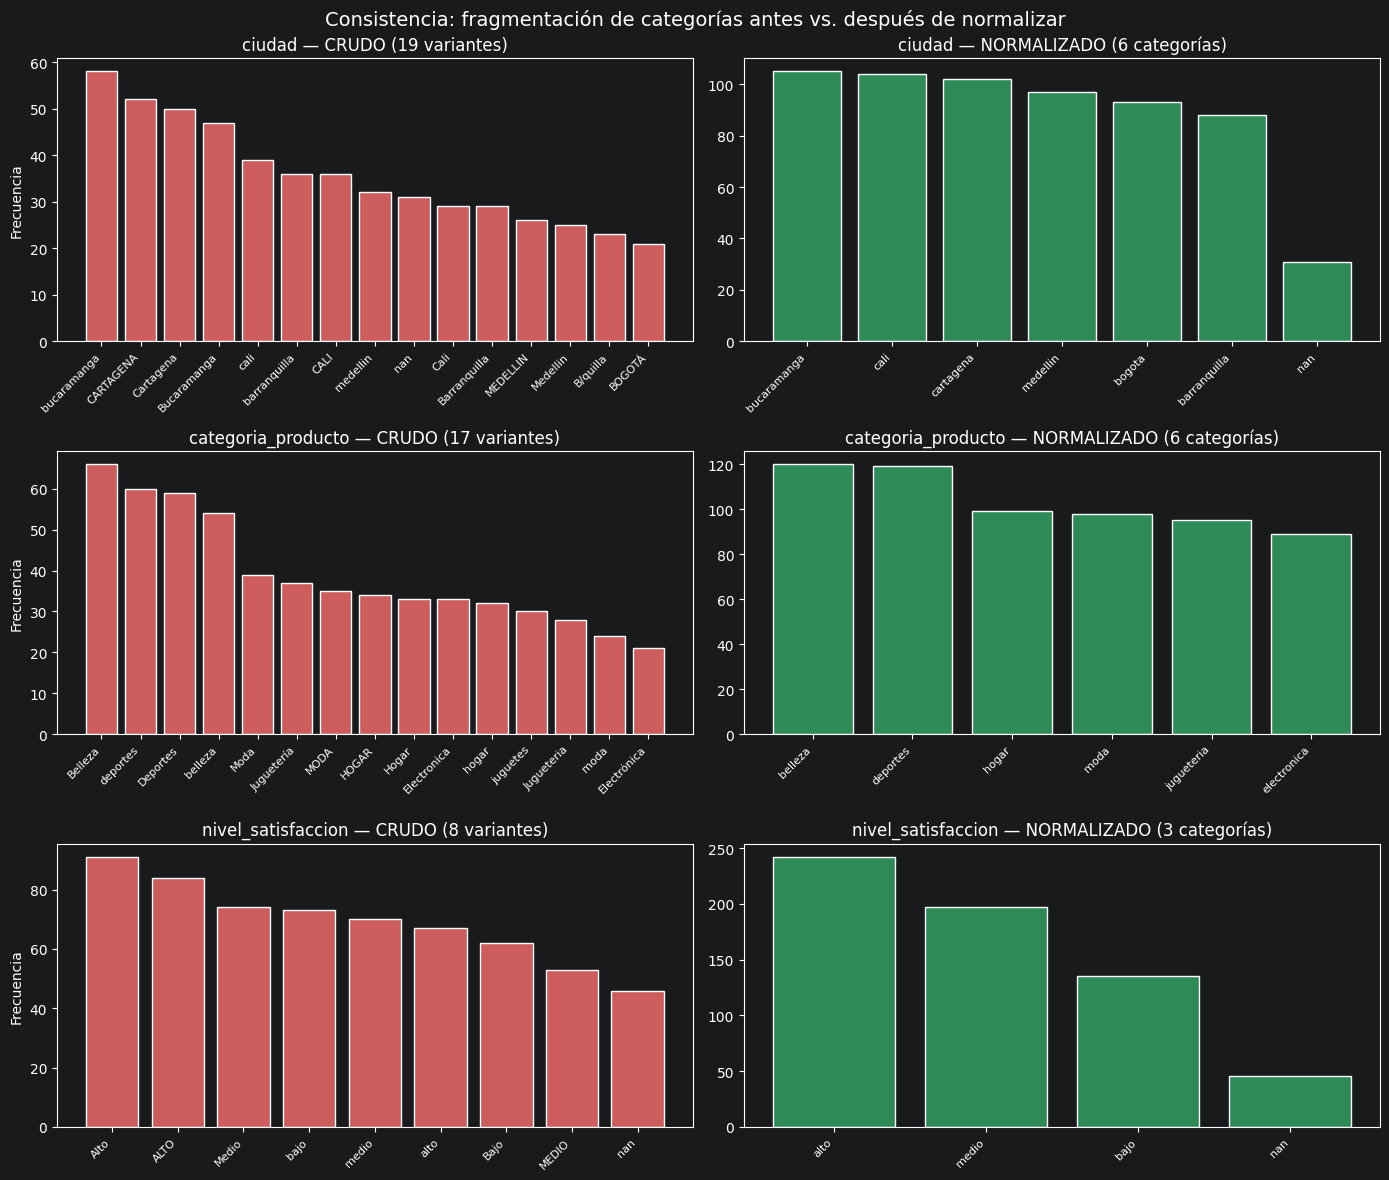

In [97]:
# Barras antes/despues para las columnas categoricas prioritarias
# Reutiliza las series normalizadas ya calculadas: ciudad_norm y cat_norm.
nivel_norm = df['nivel_satisfaccion'].map(normalizar)

comparaciones = [
    ("ciudad",             df['ciudad'],             ciudad_norm),
    ("categoria_producto", df['categoria_producto'], cat_norm),
    ("nivel_satisfaccion", df['nivel_satisfaccion'], nivel_norm),
]

fig, axes = plt.subplots(len(comparaciones), 2, figsize=(14, 12))
for fila, (nombre, cruda, norm) in enumerate(comparaciones):
    vc_crudo = cruda.value_counts(dropna=False).head(15)
    vc_norm  = norm.value_counts(dropna=False).head(15)

    axes[fila, 0].bar(range(len(vc_crudo)), vc_crudo.values,
                      color="indianred", edgecolor="white")
    axes[fila, 0].set_xticks(range(len(vc_crudo)))
    axes[fila, 0].set_xticklabels(vc_crudo.index.astype(str), rotation=45, ha="right", fontsize=8)
    axes[fila, 0].set_title(f"{nombre} — CRUDO ({cruda.nunique()} variantes)")
    axes[fila, 0].set_ylabel("Frecuencia")

    axes[fila, 1].bar(range(len(vc_norm)), vc_norm.values,
                      color="seagreen", edgecolor="white")
    axes[fila, 1].set_xticks(range(len(vc_norm)))
    axes[fila, 1].set_xticklabels(vc_norm.index.astype(str), rotation=45, ha="right", fontsize=8)
    axes[fila, 1].set_title(f"{nombre} — NORMALIZADO ({norm.nunique()} categorías)")

plt.suptitle("Consistencia: fragmentación de categorías antes vs. después de normalizar",
             fontsize=14)
plt.tight_layout()
plt.show()


### Exactitud

Se contrasta el dato contra una fuente de verdad externa (el catálogo oficial de códigos postales de Colombia, 4-72 / Datos Abiertos). Se cruza el código postal para obtener el municipio que oficialmente representa y se compara contra la ciudad declarada en la base.

In [98]:
url_ref = "https://www.datos.gov.co/resource/ixig-z8b5.csv?$limit=50000"
ref = pd.read_csv(url_ref)

equivalencias = {
    'b/quilla':    'barranquilla',
    'bogota d.c.': 'bogota',
    'bogota dc':   'bogota',
    'bogota, d.c.':'bogota',
}

def normalizar(s):
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    s = ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    return equivalencias.get(s, s)

url_ref = "https://www.datos.gov.co/resource/ixig-z8b5.csv?$limit=50000"
ref = pd.read_csv(url_ref)

ref['cp_norm'] = (
    ref['codigo_postal'].astype('string')
       .str.replace('.', '', regex=False)
       .str.strip()
       .str.zfill(6)
)
ref['municipio_norm'] = ref['nombre_municipio'].map(normalizar)

cp_a_codmun   = ref.groupby('cp_norm')['codigo_municipio'].first().to_dict()
cp_a_ciudadof = ref.groupby('cp_norm')['municipio_norm'].first().to_dict()

col = 'codigo_postal'

work = df.copy()
work['ciudad_norm'] = work['ciudad'].map(normalizar)
work['cp_norm'] = (
    work[col].astype('Int64').astype('string')
        .str.strip()
        .str.zfill(6)
)
work['codmun_oficial']  = work['cp_norm'].map(cp_a_codmun)
work['ciudad_oficial']  = work['cp_norm'].map(cp_a_ciudadof)

work['coincide'] = work.apply(
    lambda r: None if pd.isna(r['ciudad_oficial']) else (r['ciudad_norm'] == r['ciudad_oficial']),
    axis=1
).astype('object')


n = len(df)

tabla = (
    work.groupby(['ciudad', 'cp_norm', 'codmun_oficial', 'ciudad_oficial', 'coincide'], dropna=False)
        .size()
        .reset_index(name='registros')
        .rename(columns={
            'ciudad':          'ciudad_bd',
            'cp_norm':          'codigo_postal',
            'codmun_oficial':   'codigo_municipio',
            'ciudad_oficial':   'ciudad_que_representa',
        })
)
tabla['%_del_total'] = (tabla['registros'] / n * 100).round(2).astype(str) + '%'
tabla = tabla.sort_values('registros', ascending=False)

tabla_mal = tabla[tabla['coincide'] == False]

display(tabla_mal.style.hide(axis="index"))

total_mal = (work['coincide'] == False).sum()
print(f"Registros mal (ciudad ≠ ciudad del código): {total_mal} de {n} ({total_mal/n*100:.2f}%)")

ciudad_bd,codigo_postal,codigo_municipio,ciudad_que_representa,coincide,registros,%_del_total
nan,076001,76001.000000,cali,False,5,0.81%
nan,008001,8001.000000,barranquilla,False,5,0.81%
nan,005001,5001.000000,medellin,False,4,0.65%
nan,013001,13001.000000,cartagena,False,3,0.48%
bucaramanga,008001,8001.000000,barranquilla,False,2,0.32%
Bucaramanga,013001,13001.000000,cartagena,False,2,0.32%
barranquilla,013001,13001.000000,cartagena,False,2,0.32%
bucaramanga,013001,13001.000000,cartagena,False,1,0.16%
medellin,076001,76001.000000,cali,False,1,0.16%
cali,005001,5001.000000,medellin,False,1,0.16%


Registros mal (ciudad ≠ ciudad del código): 45 de 620 (7.26%)


### Unicidad

Se verifica que no existan duplicados en el identificador de pedido, que debe ser único por registro.

In [99]:
col = 'id_pedido'
n = len(df)

total_dup_filas     = df[col].duplicated().sum()              # copias que sobran
total_ids_repetidos = (df[col].value_counts() > 1).sum()      # IDs distintos repetidos

pct_dup = total_dup_filas / n * 100

audit_unicidad = pd.DataFrame([{
    "Columna":                col,
    "Registros":              n,
    "Filas Duplicadas":       total_dup_filas,
    "IDs Distintos Repetidos": total_ids_repetidos,
    "% Falla":                f"{pct_dup:.2f}%",
}])

audit_unicidad.style.hide(axis="index")


Columna,Registros,Filas Duplicadas,IDs Distintos Repetidos,% Falla
id_pedido,620,20,20,3.23%


### Oportunidad

Se verifica que las fechas tengan sentido temporal: se marcan como fuera de rango las fechas posteriores a la fecha actual (fechas futuras), que no deberían existir en registros de compra o de actualización de stock.

In [100]:
# Ya lo habíamos calculado en "fuera de rango".
audit_temporalidad = pd.DataFrame([
    {
        "Columna":         "fecha_compra",
        "Registros":       len(df),
        "Fuera de Rango":  total_purchase_out_of_range,
        "% Falla":         f"{total_purchase_out_of_range / len(df) * 100:.2f}%",
    },
    {
        "Columna":         "fecha_actualizacion_stock",
        "Registros":       len(df),
        "Fuera de Rango":  total_stock_out_of_range,
        "% Falla":         f"{total_stock_out_of_range / len(df) * 100:.2f}%",
    },
])

audit_temporalidad.style.hide(axis="index")


Columna,Registros,Fuera de Rango,% Falla
fecha_compra,620,126,20.32%
fecha_actualizacion_stock,620,21,3.39%


## 3. Catálogo de problemas


| # | Problema | Dimensión | Columnas afectadas | Nº registros |      % | Impacto |
|---|----------|-----------|--------------------|-------------:|-------:|---------|
| 1 | Inconsistencia de escritura (mayúsculas/tildes/variantes) en ciudad | Consistencia | ciudad |          351 | 59.59% | Alto    |
| 2 | Inconsistencia de escritura en nivel_satisfaccion (Alto/Medio/Bajo en varios casings) | Consistencia | nivel_satisfaccion |          336 | 58.54% | Alto    |
| 3 | Inconsistencia de escritura en categoria_producto | Consistencia | categoria_producto |          321 | 51.77% | Alto    |
| 4 | Fechas futuras en fecha_compra | Oportunidad | fecha_compra |          126 | 20.32% | Alto    |
| 5 | Código postal no corresponde a la ciudad (contra fuente oficial) | Exactitud | ciudad, codigo_postal |           45 |  7.26% | Medio   |
| 6 | Valores faltantes en correo | Completitud | correo |          104 | 16.77% | Bajo    |
| 7 | Correos con formato inválido (sin @) | Validez | correo |           51 |  8.23% | Medio   |
| 8 | Valores faltantes en nivel_satisfaccion | Completitud | nivel_satisfaccion |           46 |  7.42% | Medio   |
| 9 | edad_cliente fuera de rango (negativa o >120) | Validez | edad_cliente |           32 |  5.16% | Medio   |
| 10 | unidades ≤ 0 (negativas o cero) | Validez | unidades |           31 |  5.00% | Medio   |
| 11 | Valores faltantes en ciudad | Completitud | ciudad |           31 |  5.00% | Medio   |
| 12 | Formato de fecha no reconocible en fecha_compra | Validez | fecha_compra |           22 |  3.55% | Medio   |
| 13 | fecha_actualizacion_stock futura | Oportunidad | fecha_actualizacion_stock |           21 |  3.39% | Bajo    |
| 14 | Valores faltantes en precio | Completitud | precio |           21 |  3.39% | Medio   |
| 15 | id_pedido duplicados | Unicidad | id_pedido |           20 |  3.23% | Medio   |
| 16 | precio ≤ 0 (negativo) | Validez | precio |           19 |  3.06% | Medio   |
| 17 | unidades con valores atípicos extremos (>1000, p.ej. 9999) | Validez | unidades |           15 |  2.42% | Medio   |
| 18 | precio con valores atípicos extremos (>100M) | Validez / Exactitud | precio |            6 |  0.97% | Medio   |

**Criterio de impacto.** *Alto*: afecta a una porción amplia de registros y/o compromete análisis centrales (segmentación geográfica, series temporales, agregados de satisfacción). *Medio*: afecta variables usadas en cálculos pero en proporción moderada, o corregible con reglas claras. *Bajo*: baja proporción y/o sin efecto directo sobre métricas de negocio.